In [6]:
import hbsir
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [11]:
hbsir.setup(years="1396",method="download_cleaned",download_source="mirror")

In [17]:
import yaml

def extract_table_names(yaml_file_path):
    with open(yaml_file_path, 'r', encoding='utf-8') as file:
        schema = yaml.safe_load(file)

    table_names = set()

    # Extract top-level tables (direct keys)
    for key in schema.keys():
        if isinstance(schema[key], dict) and 'instructions' in schema[key]:
            table_names.add(key)

    # Extract tables from table_list sections
    for section in schema.values():
        if isinstance(section, dict) and 'table_list' in section:
            table_list = section['table_list']
            if isinstance(table_list, dict):
                for tables in table_list.values():
                    if isinstance(tables, list):
                        table_names.update(tables)
                    elif isinstance(tables, str):
                        table_names.add(tables)
            elif isinstance(table_list, list):
                table_names.update(table_list)

    # Remove None if present and sort alphabetically
    table_names.discard(None)
    return sorted(table_names)

# Usage example
yaml_file = r'.\schema.yaml'
tables = extract_table_names(yaml_file)
print(tables)

['Administrative_Divisions', 'Cash_Incomes', 'Equivalence_Scale', 'Expenditures', 'Imputed_Rent', 'Income_Breakdown', 'Members_Income_Breakdown', 'Members_Total_Income', 'NonCash_Incomes', 'NonCash_Incomes_Excluding_Imputed_Rent', 'Number_of_Members', 'Original_Expenditures', 'Original_Outlays', 'Outlays', 'Season', 'Total_Expenditure', 'Total_Income', 'Total_Outlay', 'Weight', '_long_other_income', 'census_month', 'cloth', 'communication', 'durable', 'education', 'employment_income', 'entertainment', 'external.hbsir_weights', 'food', 'furniture', 'home', 'hotel', 'house_specifications', 'household_information', 'investment', 'medical', 'members_properties', 'miscellaneous', 'old_rural_house_specifications', 'old_urban_house_specifications', 'other_income', 'private_employment_income', 'public_employment_income', 'self_employed_income', 'subsidy', 'tobacco', 'transportation']


In [20]:
import os

years = [1395, 1396]
tables = extract_table_names(yaml_file)

for year in years:
    for t in tables:
        try:
            print("Loading year", year)
            table = hbsir.load_table(t, years=year)
            directory_path = rf'.\csvs data\{t}\{year}'
            os.makedirs(directory_path, exist_ok=True)
            output = os.path.join(directory_path, f'{t}_{year}.csv')
            table.to_csv(output, index=False)
            print("Table", year, "done!")
        except Exception as e:
            print(f"Error processing year {year}: {e}")
            continue

Loading year 1395
Table 1395 done!
Loading year 1395


D:\regres project\venv\Lib\site-packages\bssir\data_engine.py:418: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.table[column] = self.table[column].fillna(replacement)


Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395


D:\regres project\venv\Lib\site-packages\bssir\data_engine.py:418: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.table[column] = self.table[column].fillna(replacement)


Table 1395 done!
Loading year 1395


D:\regres project\venv\Lib\site-packages\bssir\data_engine.py:418: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.table[column] = self.table[column].fillna(replacement)


Table 1395 done!
Loading year 1395


D:\regres project\venv\Lib\site-packages\bssir\data_engine.py:418: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.table[column] = self.table[column].fillna(replacement)


Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Error processing year 1395: No objects to concatenate
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Error processing year 1395: 
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 1395 done!
Loading year 1395
Table 

In [137]:
def csvfind(tableName , year ):
    return  pd.read_csv('.\\csvs data\\' + tableName +"\\"+str(year)+"\\"+tableName+"_"+str(year)+".csv")

In [138]:
expenditures_95 = csvfind(tableName="Expenditures", year=1395)

In [139]:

expenditures_95 = hbsir.add_attribute(table=expenditures_95, name='Province',year_col="Year" ,id_col="ID")
expenditures_95 = hbsir.add_attribute(table=expenditures_95, name="Urban_Rural",year_col="Year" ,id_col="ID")
expenditures_95 = hbsir.add_attribute(table=expenditures_95, name="County",year_col="Year" ,id_col="ID")


In [142]:
members_properties_95 = csvfind(tableName="members_properties", year=1395)
employment_income_95 = csvfind("employment_income",1395)

In [146]:
head_edu = members_properties_95[members_properties_95["Member_Number"] == 1][["ID", "Education_Level"]]
hh_income = employment_income_95.groupby("ID")["Annual_Continuous_Income"].sum().reset_index()
hh_income.rename(columns={"Annual_Continuous_Income": "Household_Income"}, inplace=True)

In [153]:
merged = pd.merge(hh_income, head_edu, on="ID")
merged = merged.where(pd.notnull(merged), "None")
print(merged.head())


            ID  Household_Income       Education_Level
0  10001000120        18000000.0                  None
1  10001000123        45000000.0                  None
2  10001000135       135000000.0                  None
3  10001000223       177360012.0        Pre_University
4  10001000320       271620000.0  Short_Cycle_Tertiary


In [154]:
mean_income_by_edu = merged.groupby("Education_Level")["Household_Income"].mean().sort_values(ascending=False)
print(mean_income_by_edu)


Education_Level
Doctoral                4.246935e+08
Masters                 2.928560e+08
Bachelors               2.330590e+08
Short_Cycle_Tertiary    1.882370e+08
Pre_University          1.459223e+08
Higher_Secondary        1.150528e+08
Lower_Secondary         1.144765e+08
Primary                 1.039657e+08
Unofficial              9.524174e+07
None                    9.478115e+07
Name: Household_Income, dtype: float64


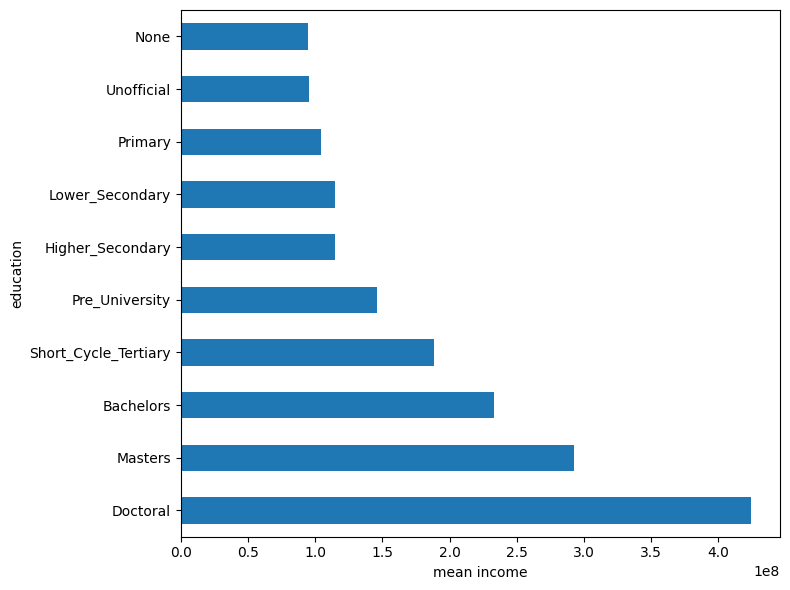

In [155]:
import matplotlib.pyplot as plt

mean_income_by_edu.plot(kind="barh", figsize=(8, 6))
plt.xlabel("mean income")
plt.ylabel("education")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from itertools import combinations

def regression_with_interactions_sklearn(df, independent_vars, target_var):
    # انتخاب داده‌ها
    X = df[independent_vars]
    y = df[target_var]

    # تبدیل متغیرهای رشته‌ای به عددی
    X = pd.get_dummies(X, drop_first=True)

    # ساخت متغیرهای تعاملی
    interaction_terms = []
    columns = list(X.columns)

    for var1, var2 in combinations(columns, 2):
        interaction_name = f'{var1}:{var2}'
        interaction_terms.append(X[var1] * X[var2])
        interaction_terms[-1].name = interaction_name

    # اضافه کردن متغیرهای تعاملی به X
    X = pd.concat([X] + interaction_terms, axis=1)

    # اضافه کردن یک ستون ثابت (intercept) برای مدل
    X['constant'] = 1

    # ساخت مدل رگرسیونی
    model = LinearRegression()

    # برازش مدل
    model.fit(X, y)

    # نمایش ضرایب
    coef_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
    return coef_df

# فرض کنید df دیتافریم شماست که شامل متغیرهای X1, X2, X3 و y است
independent_vars = ['X1', 'X2', 'X3']  # لیست ستون‌ها برای متغیرهای ورودی
target_var = 'y'  # اسم ستون هدف
df = pd.DataFrame()
result = regression_with_interactions_sklearn(df, independent_vars, target_var)
print(result)

In [ ]:
import statsmodels.api as sm
from itertools import combinations

def regression_with_interactions(df, independent_vars, target_var):
    # انتخاب داده‌ها
    X = df[independent_vars]
    y = df[target_var]

    # تبدیل متغیرهای رشته‌ای به عددی
    X = pd.get_dummies(X, drop_first=True)

    # ساختن متغیرهای تعاملی
    interaction_terms = []
    columns = list(X.columns)

    for var1, var2 in combinations(columns, 2):
        interaction_name = f'{var1}:{var2}'
        interaction_terms.append(X[var1] * X[var2])
        interaction_terms[-1].name = interaction_name

    # اضافه کردن متغیرهای تعاملی
    X = pd.concat([X] + interaction_terms, axis=1)

    # افزودن ستون ثابت
    X = sm.add_constant(X)

    # برازش مدل
    model = sm.OLS(y, X).fit()

    return model